In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_excel('American Time Use Survey.xlsx')
print(df.shape)
df.head()

(228455, 31)


,Year,SurveyID,Family Income,Housing Type,Age,Sex,Education Level,Employment Status,Occupation Type,Mins Caring for Household Members: All,...,Mins Leisure: Watching TV,Mins Personal Care,Mins Sleeping,Mins Purchasing Goods,Mins Civic and Religious Acitivites,Mins Religious and Spiritual Activities,Mins Volunteering,Mins Work Related Acitivities: All,Mins Work Related Activities: Traveling to Work,Mins Work Related Activities: Mins Working
0,2003,20030100013280,"$60,000 to $74,999",Own Home,60,Male,"Master's degree (MA, MS, MEng, MEd, MSW, etc.)",Employed,"Education, training, and library occupations",0,...,325,910,870,0,0,0,0,0,0,0
1,2003,20030100013344,Refused,Own Home,41,Female,Some college but no degree,Employed,Sales and related occupations,60,...,60,680,620,0,0,0,0,0,0,0
2,2003,20030100013352,"$75,000 to $99,999",Own Home,26,Female,Associate degree - occupational vocational,Employed,Personal care and service occupations,0,...,120,640,560,70,0,0,0,0,0,0
3,2003,20030100013848,"$20,000 to $24,999",Own Home,36,Female,High school graduate - diploma,Unemployed,NaN,5,...,265,755,720,0,0,0,0,120,0,0
4,2003,20030100014165,"$75,000 to $99,999",Own Home,51,Male,"Professional school degree (MD, DDS, DVM, etc.)",Employed,Healthcare practitioner and technical occupations,155,...,60,460,385,33,0,0,0,515,15,500


In [2]:
df.info()
df.describe()
print("Column names:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228455 entries, 0 to 228454
Data columns (total 31 columns):
 #   Column                                                   Non-Null Count   Dtype 
---  ------                                                   --------------   ----- 
 0   Year                                                     228455 non-null  int64 
 1   SurveyID                                                 228455 non-null  int64 
 2   Family Income                                            228455 non-null  object
 3   Housing Type                                             228284 non-null  object
 4   Age                                                      228455 non-null  int64 
 5   Sex                                                      228455 non-null  object
 6   Education Level                                          228455 non-null  object
 7   Employment Status                                        228455 non-null  object
 8   Occupation Type         

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

Occupation Type                                            87328
Housing Type                                                 171
Year                                                           0
Minutes Leisure: All Types                                     0
Mins Work Related Activities: Traveling to Work                0
Mins Work Related Acitivities: All                             0
Mins Volunteering                                              0
Mins Religious and Spiritual Activities                        0
Mins Civic and Religious Acitivites                            0
Mins Purchasing Goods                                          0
Mins Sleeping                                                  0
Mins Personal Care                                             0
Mins Leisure: Watching TV                                      0
Mins Leisure: Sports and Exercise                              0
Mins Leisure: Socializing                                      0
Mins Leisure: Arts and En

In [4]:
df_clean = df.copy()

df_clean = df_clean[~df_clean['Family Income'].isin(['Refused', "Don't know", 'Blank'])].copy()

df_clean = df_clean.drop(columns=['Occupation Type'])

df_clean['Housing Type'] = df_clean['Housing Type'].fillna(
    df_clean['Housing Type'].mode()[0]
)

In [5]:
income_group_map = {
    'Less than $5,000': 'Low (<$20K)',
    '$5,000 to $7,499': 'Low (<$20K)',
    '$7,500 to $9,999': 'Low (<$20K)',
    '$10,000 to $12,499': 'Low (<$20K)',
    '$12,500 to $14,999': 'Low (<$20K)',
    '$15,000 to $19,999': 'Low (<$20K)',

    '$20,000 to $24,999': 'Lower-Mid ($20K–$50K)',
    '$25,000 to $29,999': 'Lower-Mid ($20K–$50K)',
    '$30,000 to $34,999': 'Lower-Mid ($20K–$50K)',
    '$35,000 to $39,999': 'Lower-Mid ($20K–$50K)',
    '$40,000 to $49,999': 'Lower-Mid ($20K–$50K)',

    '$50,000 to $59,999': 'Upper-Mid ($50K–$100K)',
    '$60,000 to $74,999': 'Upper-Mid ($50K–$100K)',
    '$75,000 to $99,999': 'Upper-Mid ($50K–$100K)',

    '$100,000 to $149,999': 'High (>$100K)',
    '$150,000 and over': 'High (>$100K)',
}

df_clean['Income Group'] = df_clean['Family Income'].map(income_group_map)


In [6]:
df_clean['Period'] = df_clean['Year'].apply(
    lambda x: 'Pre-COVID (≤2019)' if x <= 2019 else 'COVID (2020–2021)'
)


In [7]:
print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values per column:")
print(df_clean.isnull().sum().sort_values(ascending=False).head(10))

print("\nCount per income group:")
print(df_clean['Income Group'].value_counts())

print("\nCount per period:")
print(df_clean['Period'].value_counts())

df_clean.head()

Cleaned dataset shape: (214757, 32)

Missing values per column:
Year                                               0
SurveyID                                           0
Income Group                                       0
Mins Work Related Activities: Mins Working         0
Mins Work Related Activities: Traveling to Work    0
Mins Work Related Acitivities: All                 0
Mins Volunteering                                  0
Mins Religious and Spiritual Activities            0
Mins Civic and Religious Acitivites                0
Mins Purchasing Goods                              0
dtype: int64

Count per income group:
Income Group
Upper-Mid ($50K–$100K)    68510
Lower-Mid ($20K–$50K)     68263
High (>$100K)             39986
Low (<$20K)               37998
Name: count, dtype: int64

Count per period:
Period
Pre-COVID (≤2019)    196888
COVID (2020–2021)     17869
Name: count, dtype: int64


,Year,SurveyID,Family Income,Housing Type,Age,Sex,Education Level,Employment Status,Mins Caring for Household Members: All,Mins Caring for Household Members: Adults,...,Mins Sleeping,Mins Purchasing Goods,Mins Civic and Religious Acitivites,Mins Religious and Spiritual Activities,Mins Volunteering,Mins Work Related Acitivities: All,Mins Work Related Activities: Traveling to Work,Mins Work Related Activities: Mins Working,Income Group,Period
0,2003,20030100013280,"$60,000 to $74,999",Own Home,60,Male,"Master's degree (MA, MS, MEng, MEd, MSW, etc.)",Employed,0,0,...,870,0,0,0,0,0,0,0,Upper-Mid ($50K–$100K),Pre-COVID (≤2019)
2,2003,20030100013352,"$75,000 to $99,999",Own Home,26,Female,Associate degree - occupational vocational,Employed,0,0,...,560,70,0,0,0,0,0,0,Upper-Mid ($50K–$100K),Pre-COVID (≤2019)
3,2003,20030100013848,"$20,000 to $24,999",Own Home,36,Female,High school graduate - diploma,Unemployed,5,0,...,720,0,0,0,0,120,0,0,Lower-Mid ($20K–$50K),Pre-COVID (≤2019)
4,2003,20030100014165,"$75,000 to $99,999",Own Home,51,Male,"Professional school degree (MD, DDS, DVM, etc.)",Employed,155,0,...,385,33,0,0,0,515,15,500,Upper-Mid ($50K–$100K),Pre-COVID (≤2019)
5,2003,20030100014169,"$40,000 to $49,999",Own Home,32,Female,"Bachelor's degree (BA, AB, BS, etc.)",Employed,245,0,...,675,0,0,0,0,0,0,0,Lower-Mid ($20K–$50K),Pre-COVID (≤2019)


In [8]:
key_act_cols = {
    'Work': 'Mins Work Related Activities: Mins Working',
    'Leisure': 'Minutes Leisure: All Types',
    'Household': 'Mins Household Activities: All',
    'Exercise': 'Mins Leisure: Sports and Exercise',
    'TV': 'Mins Leisure: Watching TV',
    'Sleep': 'Mins Sleeping'
}


income_order = [
    'Low (<$20K)',
    'Lower-Mid ($20K–$50K)',
    'Upper-Mid ($50K–$100K)',
    'High (>$100K)'
]

In [9]:
income_means = (
    df_clean
    .groupby('Income Group')[[v for v in key_act_cols.values()]]
    .mean()
    .loc[income_order]  
    / 60
)

income_means.columns = list(key_act_cols.keys())

print("Average daily hours for each activity by income group:")
print(income_means.round(2))

Average daily hours for each activity by income group:
                        Work  Leisure  Household  Exercise    TV  Sleep
Income Group                                                           
Low (<$20K)             1.38     6.63       2.03      0.20  3.91   9.35
Lower-Mid ($20K–$50K)   2.44     5.75       2.08      0.25  3.17   8.94
Upper-Mid ($50K–$100K)  3.04     5.10       2.09      0.33  2.54   8.65
High (>$100K)           3.23     4.74       2.05      0.41  2.16   8.54


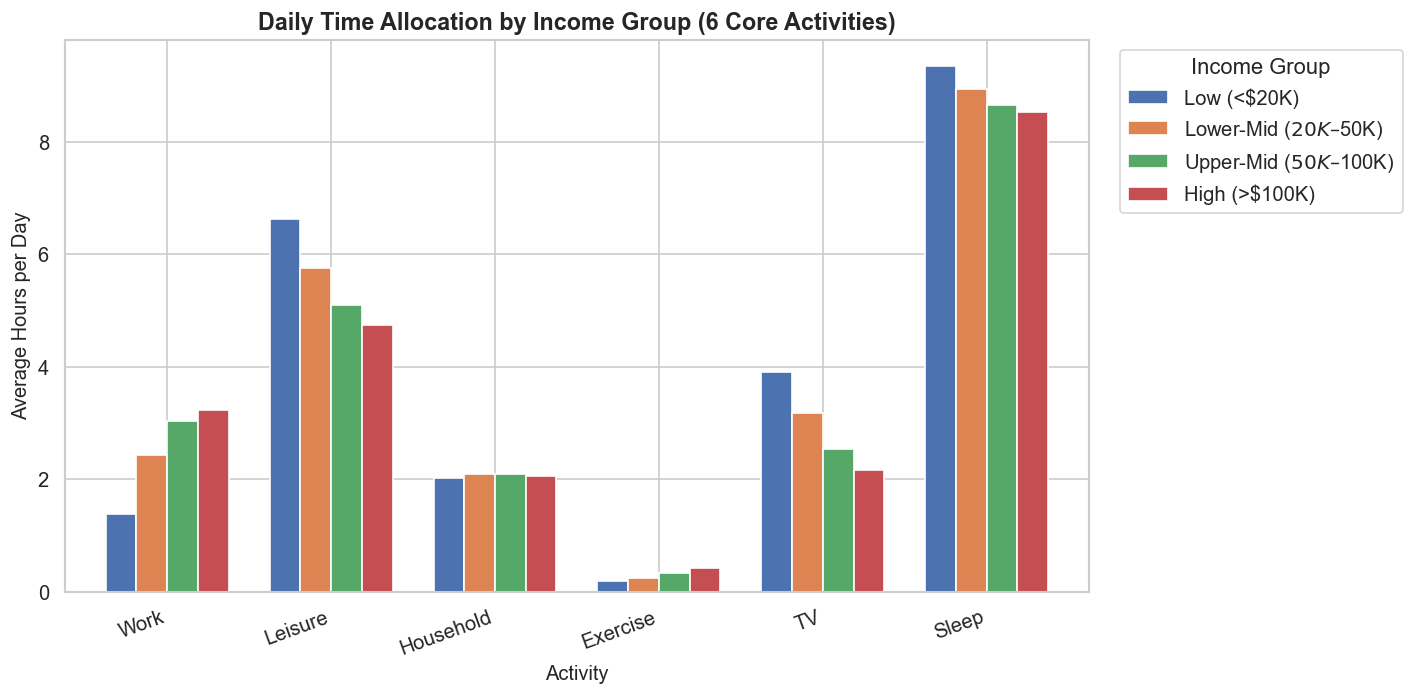

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

income_means.T.plot(
    kind='bar',
    ax=ax,
    width=0.75,
    edgecolor='white'
)

ax.set_title('Daily Time Allocation by Income Group (6 Core Activities)', fontsize=14, fontweight='bold')
ax.set_xlabel('Activity', fontsize=12)
ax.set_ylabel('Average Hours per Day', fontsize=12)
ax.legend(title='Income Group', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [11]:
pre_covid = df_clean[df_clean['Period'] == 'Pre-COVID (≤2019)']
covid = df_clean[df_clean['Period'] == 'COVID (2020–2021)']

pre_means = pre_covid[[v for v in key_act_cols.values()]].mean() / 60
covid_means = covid[[v for v in key_act_cols.values()]].mean() / 60

pre_means.index = list(key_act_cols.keys())
covid_means.index = list(key_act_cols.keys())

period_comparison = pd.DataFrame({
    'Pre-COVID': pre_means,
    'COVID': covid_means,
    'Change (hours)': (covid_means - pre_means)
})

print("Average daily hours before and during COVID:")
print(period_comparison.round(2))

Average daily hours before and during COVID:
           Pre-COVID  COVID  Change (hours)
Work            2.61   2.43           -0.18
Leisure         5.48   5.84            0.35
Household       2.05   2.28            0.23
Exercise        0.29   0.33            0.04
TV              2.88   3.28            0.40
Sleep           8.83   9.06            0.23


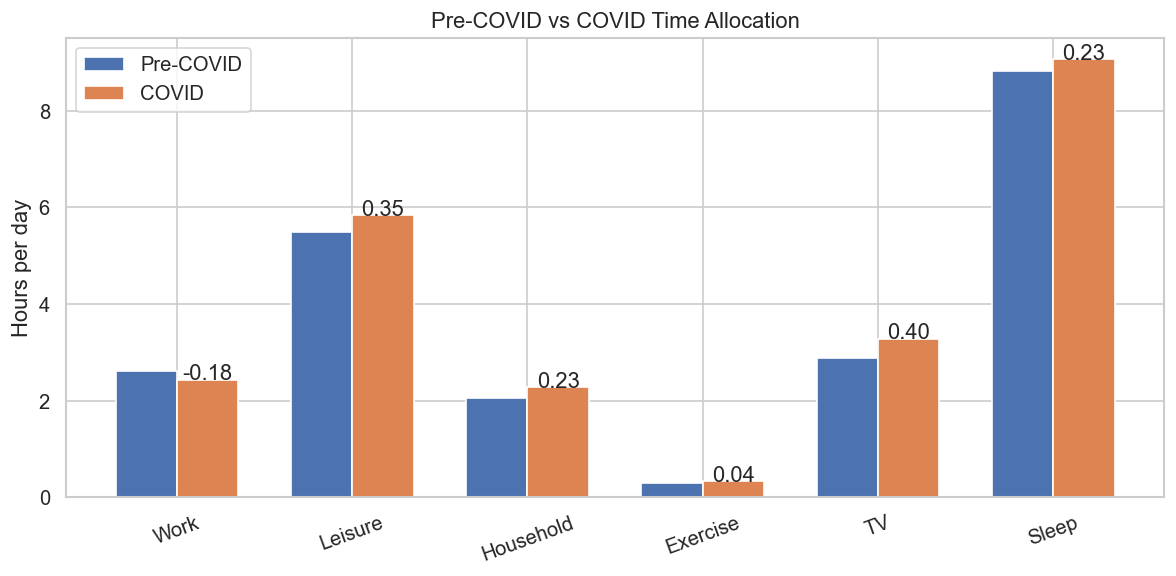

In [12]:
x = np.arange(len(key_act_cols))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, pre_means.values, width, label='Pre-COVID')

plt.bar(x + width/2, covid_means.values, width, label='COVID')

for i in range(len(key_act_cols)):
    diff = covid_means.values[i] - pre_means.values[i]
    
    plt.text(
        x[i] + width/2,
        covid_means.values[i],
        f'{diff:.2f}',
        ha='center'
    )

plt.xticks(x, list(key_act_cols.keys()), rotation=20)
plt.ylabel('Hours per day')
plt.title('Pre-COVID vs COVID Time Allocation')
plt.legend()

plt.tight_layout()
plt.show()

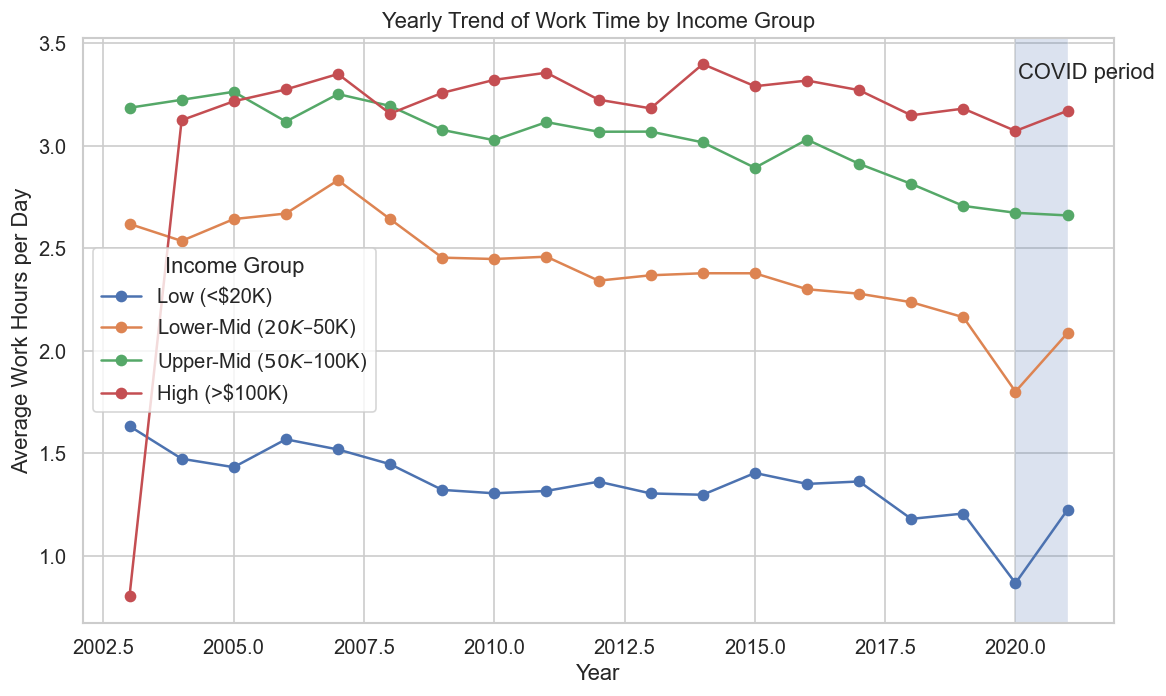

In [13]:
work_col = 'Mins Work Related Activities: Mins Working'

year_income_work = (
    df_clean
    .groupby(['Year', 'Income Group'])[work_col]
    .mean()
    .reset_index()
)

year_income_work['Work Hours'] = year_income_work[work_col] / 60

income_order = [
    'Low (<$20K)',
    'Lower-Mid ($20K–$50K)',
    'Upper-Mid ($50K–$100K)',
    'High (>$100K)'
]

plt.figure(figsize=(10, 6))

for group in income_order:
    temp = year_income_work[year_income_work['Income Group'] == group]
    plt.plot(temp['Year'], temp['Work Hours'], marker='o', label=group)

plt.axvspan(2020, 2021, alpha=0.2)

y_max = year_income_work['Work Hours'].max()
plt.text(2020.05, y_max * 0.98, 'COVID period')

plt.title('Yearly Trend of Work Time by Income Group')
plt.xlabel('Year')
plt.ylabel('Average Work Hours per Day')
plt.legend(title='Income Group')

plt.tight_layout()
plt.show()

In [15]:
def cohens_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    pooled_std = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    if pooled_std == 0:
        return np.nan
    return (y.mean() - x.mean()) / pooled_std

stats_results = []

for act_name, col in key_act_cols.items():
    pre_vals = pre_covid[col]
    covid_vals = covid[col]

    t_stat, p_val = stats.ttest_ind(pre_vals, covid_vals, equal_var=False)
    d = cohens_d(pre_vals, covid_vals)

    stats_results.append({
        'Activity': act_name,
        'Pre Mean (hrs)': pre_vals.mean() / 60,
        'COVID Mean (hrs)': covid_vals.mean() / 60,
        'Change (hrs)': (covid_vals.mean() - pre_vals.mean()) / 60,
        't-statistic': t_stat,
        'p-value': p_val,
        'Cohen_d': d
    })

stats_df = pd.DataFrame(stats_results).sort_values(by='Change (hrs)', key=np.abs, ascending=False)

print("Statistical comparison: Pre-COVID vs COVID")
display(stats_df.round(4))

Statistical comparison: Pre-COVID vs COVID


,Activity,Pre Mean (hrs),COVID Mean (hrs),Change (hrs),t-statistic,p-value,Cohen_d
4,TV,2.8785,3.2786,0.4001,-15.9861,0.0,0.1345
1,Leisure,5.4824,5.8373,0.3549,-11.9469,0.0,0.0959
5,Sleep,8.8259,9.0577,0.2318,-13.3633,0.0,0.1026
2,Household,2.0501,2.2759,0.2258,-11.6349,0.0,0.0951
0,Work,2.6054,2.4291,-0.1763,5.7206,0.0,-0.0441
3,Exercise,0.2911,0.3321,0.0411,-5.7192,0.0,0.0441


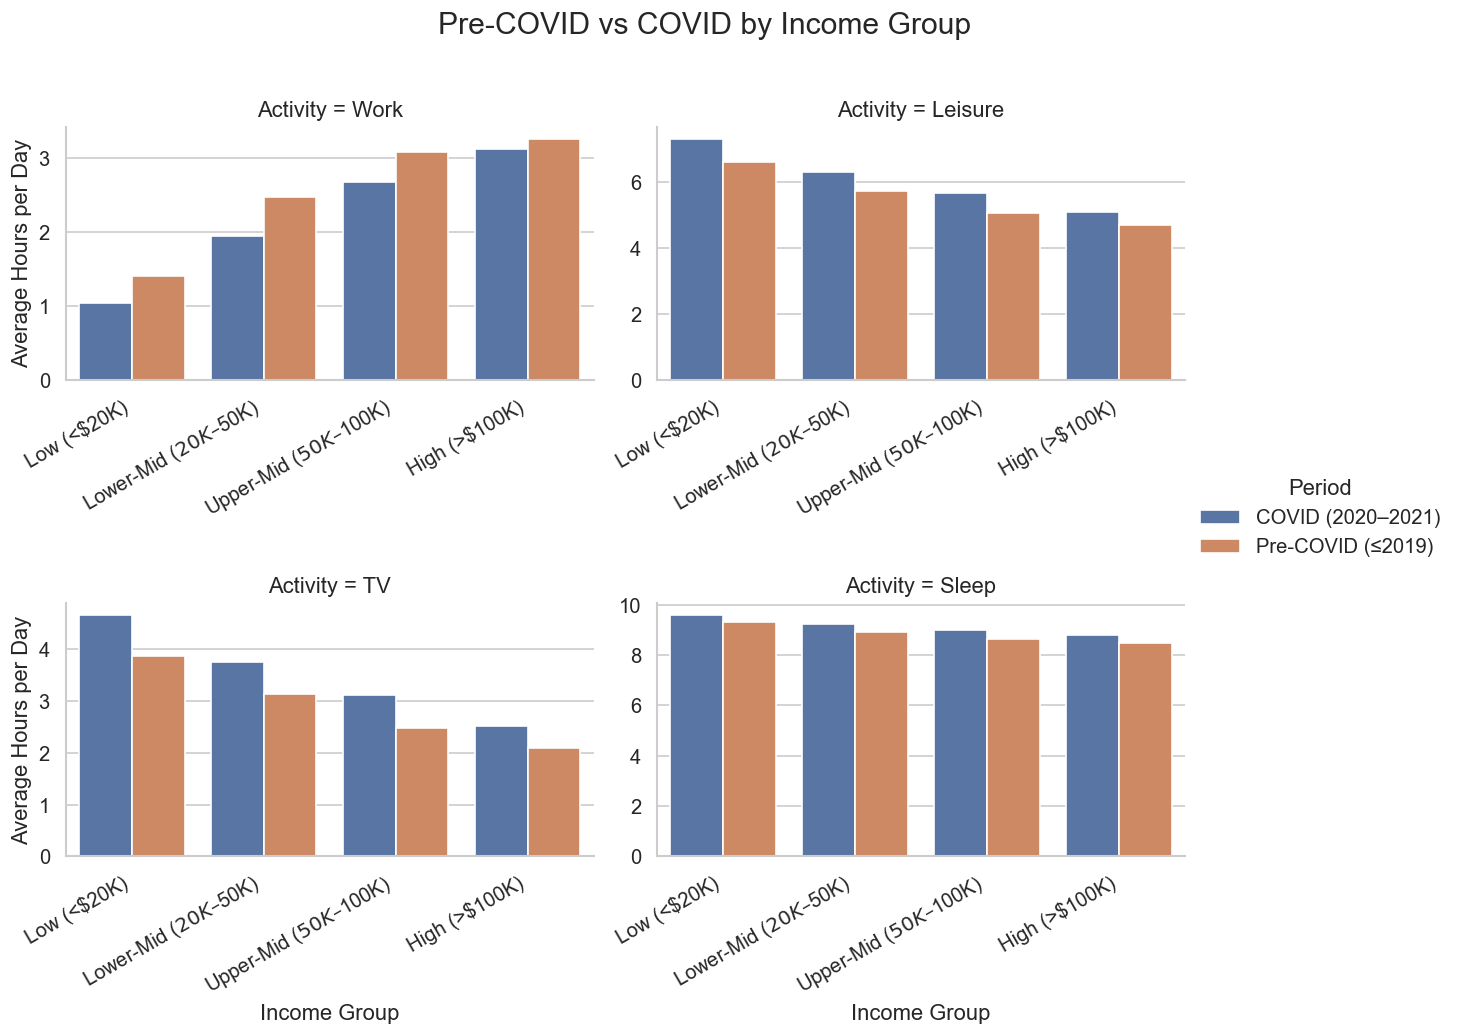

In [29]:
group_period_means = (
    df_clean
    .groupby(['Income Group', 'Period'])[[v for v in key_act_cols.values()]]
    .mean()
    .reset_index()
)

group_period_means['Income Group'] = pd.Categorical(
    group_period_means['Income Group'],
    categories=income_order,
    ordered=True
)

plot_df = group_period_means.melt(
    id_vars=['Income Group', 'Period'],
    value_vars=list(key_act_cols.values()),
    var_name='Activity Column',
    value_name='Minutes'
)

reverse_act_cols = {v: k for k, v in key_act_cols.items()}
plot_df['Activity'] = plot_df['Activity Column'].map(reverse_act_cols)
plot_df['Hours'] = plot_df['Minutes'] / 60


focus_acts = ['Work', 'Leisure', 'TV', 'Sleep']
plot_df_focus = plot_df[plot_df['Activity'].isin(focus_acts)]

g = sns.catplot(
    data=plot_df_focus,
    x='Income Group',
    y='Hours',
    hue='Period',
    col='Activity',
    kind='bar',
    col_wrap=2,
    height=4,
    aspect=1.3,
    sharey=False
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', labelbottom=True)
    ax.set_xticks(range(4))  
    ax.set_xticklabels(
        ['Low (<$20K)', 'Lower-Mid ($20K–$50K)', 'Upper-Mid ($50K–$100K)', 'High (>$100K)'], 
        rotation=30, ha='right'
    )
    

g.set_axis_labels("Income Group", "Average Hours per Day")
g.fig.suptitle("Pre-COVID vs COVID by Income Group")

g.fig.subplots_adjust(top=0.86, bottom=0.10, wspace=0.12, hspace=0.88)
g.fig.suptitle("Pre-COVID vs COVID by Income Group", fontsize=18)

plt.show()

In [33]:
df_model = df_clean.copy()

df_model['COVID'] = (df_model['Year'] >= 2020).astype(int)

df_model = df_model.rename(columns={
    'Mins Work Related Activities: Mins Working': 'work_mins',
    'Minutes Leisure: All Types': 'leisure_mins',
    'Mins Household Activities: All': 'household_mins',
    'Mins Leisure: Sports and Exercise': 'exercise_mins',
    'Mins Leisure: Watching TV': 'tv_mins',
    'Mins Sleeping': 'sleep_mins'
})

outcome_vars = ['work_mins', 'leisure_mins', 'household_mins', 'exercise_mins', 'tv_mins', 'sleep_mins']

X_base = df_model[['COVID', 'Age']].copy()

X_cat = pd.get_dummies(
    df_model[['Sex', 'Employment Status', 'Income Group']],
    drop_first=True
)

X = pd.concat([X_base, X_cat], axis=1)

X.insert(0, 'Intercept', 1)

X = X.astype(float)

regression_results = []

for outcome in outcome_vars:
    y = df_model[outcome].astype(float).values
    X_mat = X.values

    # OLS: beta = (X'X)^(-1) X'y
    beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]

    y_pred = X_mat @ beta

    # R-squared
    ss_total = np.sum((y - y.mean()) ** 2)
    ss_resid = np.sum((y - y_pred) ** 2)
    r_squared = 1 - ss_resid / ss_total

    covid_idx = list(X.columns).index('COVID')
    covid_coef = beta[covid_idx]

    regression_results.append({
        'Outcome': outcome,
        'COVID Coef (mins)': covid_coef,
        'R-squared': r_squared
    })

regression_df = pd.DataFrame(regression_results)

print("Regression results: effect of COVID after controls")
display(regression_df.round(4))

Regression results: effect of COVID after controls


,Outcome,COVID Coef (mins),R-squared
0,work_mins,-0.9912,0.2578
1,leisure_mins,13.9708,0.1555
2,household_mins,7.4314,0.0554
3,exercise_mins,1.5678,0.0225
4,tv_mins,21.1532,0.1305
5,sleep_mins,19.1136,0.0392


In [36]:
interaction_results = []

for outcome in outcome_vars:
    X_base = df_model[['COVID', 'Age']].copy()

    X_cat = pd.get_dummies(
        df_model[['Sex', 'Employment Status', 'Income Group']],
        drop_first=True
    )

    income_dummy_cols = [col for col in X_cat.columns if col.startswith('Income Group_')]

    X_interaction = pd.DataFrame(index=df_model.index)
    for col in income_dummy_cols:
        X_interaction[f'COVID_x_{col}'] = df_model['COVID'] * X_cat[col]

    X = pd.concat([X_base, X_cat, X_interaction], axis=1)
    X.insert(0, 'Intercept', 1)
    X = X.astype(float)
    y = df_model[outcome].astype(float).values
    X_mat = X.values

    beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]
    y_pred = X_mat @ beta

    ss_total = np.sum((y - y.mean()) ** 2)
    ss_resid = np.sum((y - y_pred) ** 2)
    r_squared = 1 - ss_resid / ss_total

    coef_series = pd.Series(beta, index=X.columns)

    base_covid_effect = coef_series.get('COVID', np.nan)

    interaction_term_names = [col for col in X.columns if col.startswith('COVID_x_')]
    interaction_term_values = coef_series[interaction_term_names]

    interaction_results.append({
        'Outcome': outcome,
        'Base COVID Effect': base_covid_effect,
        'Interaction Terms Found': len(interaction_term_names),
        'Max Interaction Effect': interaction_term_values.max() if len(interaction_term_values) > 0 else np.nan,
        'Min Interaction Effect': interaction_term_values.min() if len(interaction_term_values) > 0 else np.nan,
        'Model R-squared': r_squared
    })

interaction_df = pd.DataFrame(interaction_results)

print("Interaction model summary")
display(interaction_df.round(4))

Interaction model summary


,Outcome,Base COVID Effect,Interaction Terms Found,Max Interaction Effect,Min Interaction Effect,Model R-squared
0,work_mins,0.6250,3,1.3163,-5.8715,0.2578
1,leisure_mins,15.4539,3,6.0122,-3.7888,0.1555
2,household_mins,11.5471,3,-3.7917,-11.4491,0.0555
3,exercise_mins,3.7637,3,-1.5767,-4.0902,0.0225
4,tv_mins,18.2265,3,14.3109,2.0121,0.1305
5,sleep_mins,18.6755,3,2.8153,-3.0186,0.0392
